In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

sns.set_style("whitegrid")  ## for better plot appearance


In [2]:
df = pd.read_csv("../northbeam_accounts_clean.csv")

In [3]:
df.describe()

,contract_value,seats_licensed,seats_active,mau_m5,mau_m4,mau_m3,mau_m2,mau_m1,mau_m0,support_tickets_90d,escalations_90d,csat,data_quality_flag
count,4.240000e+02,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,194.000000,424.000000
mean,9.192647e+04,201.580189,134.674528,82.992925,81.372642,77.608491,71.823113,69.214623,65.181604,4.573113,0.747642,3.708763,0.030660
std,2.158869e+05,327.647670,242.465289,169.800766,164.123873,153.878978,150.319060,148.807915,153.742770,2.629948,0.891247,0.674537,0.172599
min,-4.500000e+03,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000,0.000000
25%,3.544005e+03,25.000000,16.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,3.000000,0.000000,3.100000,0.000000
50%,9.726250e+03,68.000000,39.500000,18.500000,18.000000,19.000000,16.000000,15.500000,13.000000,4.000000,1.000000,3.700000,0.000000
75%,7.260744e+04,200.250000,124.000000,74.250000,69.250000,72.000000,68.250000,70.000000,60.250000,6.000000,1.000000,4.200000,0.000000
max,1.322116e+06,1488.000000,1301.000000,1206.000000,1151.000000,1147.000000,1080.000000,1069.000000,1154.000000,13.000000,6.000000,5.000000,1.000000


In [4]:
date_columns = [
    "signup_date",
    "contract_start_date",
    "contract_end_date",
    "last_login_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")



In [5]:
print(df.dtypes)

account_id                        str
account_name                      str
segment                           str
industry                          str
region                            str
signup_date            datetime64[us]
contract_start_date    datetime64[us]
contract_end_date      datetime64[us]
billing_term                      str
contract_value                float64
seats_licensed                  int64
seats_active                    int64
mau_m5                          int64
mau_m4                          int64
mau_m3                          int64
mau_m2                          int64
mau_m1                          int64
mau_m0                          int64
support_tickets_90d             int64
escalations_90d                 int64
last_login_date        datetime64[us]
csat                          float64
data_quality_flag               int64
dtype: object


In [6]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns

categorical_cols

Index(['account_id', 'account_name', 'segment', 'industry', 'region',
       'billing_term'],
      dtype='str')

In [7]:
for col in categorical_cols:
    print("=" * 50)
    print(col)
    print(df[col].value_counts())
    print()

account_id
account_id
ACC-1132    1
ACC-1341    1
ACC-1118    1
ACC-1212    1
ACC-1096    1
           ..
ACC-1211    1
ACC-1067    1
ACC-1025    1
ACC-1196    1
ACC-1175    1
Name: count, Length: 424, dtype: int64

account_name
account_name
Solace Holdings       1
Cedar Partners        1
Nimbus Industries     1
Helix Labs            1
Quill Technologies    1
                     ..
Atlas Corp            1
Zephyr Labs           1
Maple Corp            1
Harbor Media          1
Zephyr Dynamics       1
Name: count, Length: 424, dtype: int64

segment
segment
SMB           181
Mid-Market    164
Enterprise     65
Name: count, dtype: int64

industry
industry
SaaS             58
Hospitality      54
FinServ          47
Manufacturing    44
Healthcare       43
Education        43
Logistics        41
Media            38
Retail           28
Construction     28
Name: count, dtype: int64

region
region
North America    216
EMEA             119
APAC              73
LATAM             16
Name: count, d

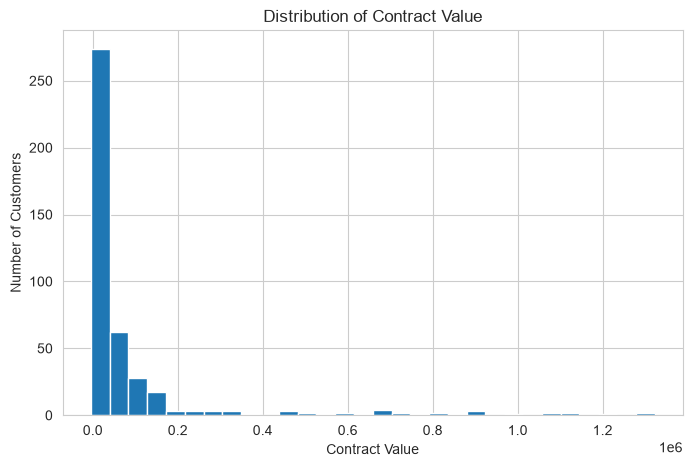

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["contract_value"], bins=30)

plt.title("Distribution of Contract Value")

plt.xlabel("Contract Value")

plt.ylabel("Number of Customers")

plt.show()

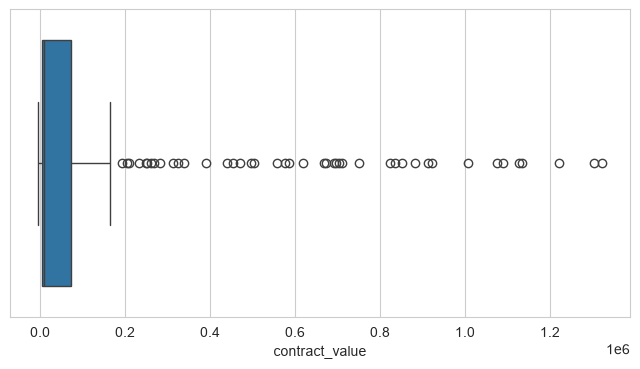

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["contract_value"])

plt.show()

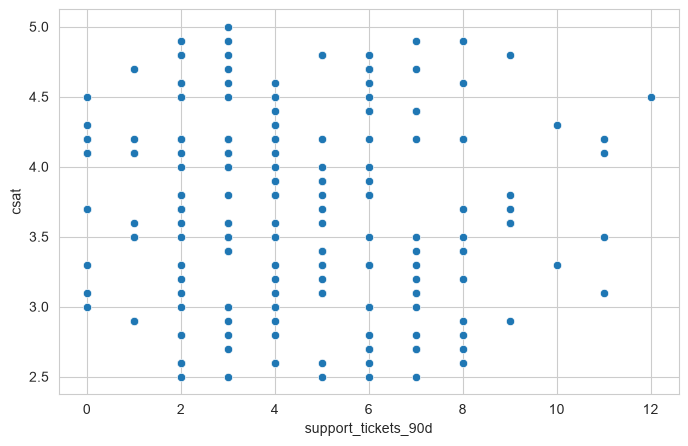

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="support_tickets_90d",
    y="csat"
)

plt.show()

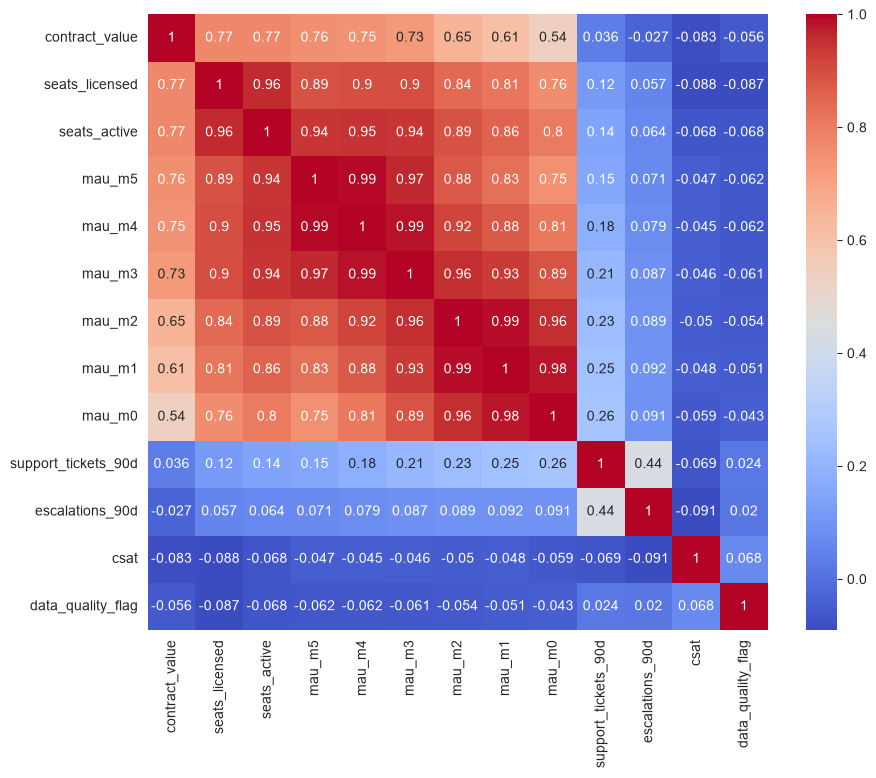

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Here in the Correlations figure we will not remove any column because we are not applying ml models.

The Positive correlation are :

-> seats_licensed - seats_active = 0.96	
-> mau_m5 - mau_m4 = 0.99	
-> mau_m4 - mau_m3 = 0.99	
-> mau_m2 - mau_m1 = 0.99	
-> mau_m1 - mau_m0 = 0.98


The Negative correlation are :

-> escalations - csat = -0.091
-> support tickets - csat = -0.069
-> contract value - csat = -0.083


No correlation are :

-> contract_value - support_tickets = 0.036